# Assignment 2 — Boilerplate vs. Substantive Sentence Classifier
**NLP for Finance — Spring 2026** | Author: Yueqi Lin

**Hard constraint:** substantive recall ≥ 0.96 on the held-out test set.

| Section | Description |
|---------|-------------|
| §1 | Environment & paths |
| §2 | Sentence extraction from 131 transcripts |
| §3 | Gold labeling: 5-judge LLM majority vote + human audit (round 3) |
| §4 | Stratified 60/20/20 split |
| §5 | Feature engineering: 384-dim embeddings + 25 regex flags |
| §6 | Classifier zoo: Rules, LogReg, HistGBM, FastText, FinBERT, SetFit + 2 ensembles |
| §7 | OOF recall-constrained threshold tuning |
| §8 | Ensemble + final test evaluation + leaderboard |
| §9 | Error analysis |

## §1 — Environment & Paths

In [1]:
# Uncomment to install in a fresh environment
# !pip install -q nltk sentence-transformers scikit-learn fasttext-wheel setfit \
#              transformers datasets accelerate pandas numpy pyarrow tqdm matplotlib plotly streamlit

import os, re, json, pickle, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Disable MPS on Apple Silicon — shared GPU memory OOMs with multiple models loaded
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT        = Path('/Users/yueqilin/Desktop/9796 NLP/Transcript Assignment2')
TRANSCRIPTS = ROOT / 'ECT'
CACHE       = ROOT / 'cache'
GOLD_DIR    = CACHE / 'gold'
EMBED_CACHE = CACHE / 'embeddings.pkl'
MODEL_DIR   = ROOT / 'saved_model'

for d in (CACHE, GOLD_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

txts = sorted(TRANSCRIPTS.glob('*.txt'))
print(f'{len(txts)} transcripts found')

131 transcripts found


/Users/yueqilin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## §2 — Sentence Extraction

Parse every transcript in `ECT/` with a rule-based speaker/section tagger, then sentence-tokenize
with NLTK Punkt. Each sentence is tagged with:

- `ticker`, `quarter`, `call_date`
- `section`: `prepared` or `qa`
- `speaker_type`: `operator`, `ir`, `executive`, `analyst`, `unknown`
- `text`: the sentence itself

Sentences shorter than 40 characters are dropped. Exact duplicates are removed.
Result: **53,236 unique sentences** cached in `cache/sentence_pool.parquet`.

In [2]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# ── Transcript parser for Assignment 2 pipeline ───────────────────────────────
SECTION_HEADERS = {
    'Presentation Operator Message',
    'Presenter Speech',
    'Question and Answer Operator Message',
    'Question',
    'Answer',
}
HEADER_RE = re.compile(
    r'^(?P<company>.+?),\s*Q(?P<q>\d)\s*(?P<y>\d{4}).*?Earnings Call.*?'
    r'(?P<date>[A-Z][a-z]+ \d{1,2},\s*\d{4})'
)

def _blocks(text):
    lines = text.splitlines()
    i, n = 0, len(lines)
    while i < n:
        line = lines[i].strip()
        if line in SECTION_HEADERS:
            section = line; i += 1
            role = lines[i].strip() if i < n else ''; i += 1
            buf = []
            while i < n and lines[i].strip() not in SECTION_HEADERS:
                buf.append(lines[i]); i += 1
            yield section, role, '\n'.join(buf).strip()
        else:
            i += 1

def _speaker_type(role: str) -> str:
    r = role.lower()
    if 'operator' in r:              return 'operator'
    if 'investor relations' in r or r.startswith('executives') and any(
            x in r for x in ['investor', 'ir ', ' ir', 'relations']): return 'ir'
    if r.startswith('executives'):   return 'executive'
    if r.startswith('analysts'):     return 'analyst'
    if r == 'operator':              return 'operator'
    return 'unknown'

def _parse_meta(path):
    text = path.read_text(errors='ignore')
    stem = path.stem
    ticker, _, quarter = stem.partition('_')
    m = HEADER_RE.match(text.splitlines()[0])
    call_date = None
    if m:
        from datetime import datetime
        try:
            call_date = datetime.strptime(m.group('date').replace('  ',' '), '%b %d, %Y').strftime('%Y-%m-%d')
        except ValueError:
            pass
    return ticker, quarter, call_date, text

# ── Sentence extraction ────────────────────────────────────────────────────────
MIN_CHARS = 40

def extract_sentences(path: Path) -> List[Dict]:
    ticker, quarter, call_date, text = _parse_meta(path)
    rows = []
    in_qa = False
    for section, role, body in _blocks(text):
        if section == 'Question and Answer Operator Message':
            in_qa = True; continue
        if not body.strip():
            continue
        sec_label = 'qa' if in_qa else 'prepared'
        spk = _speaker_type(role)
        for sent in sent_tokenize(body):
            sent = sent.strip()
            if len(sent) >= MIN_CHARS:
                rows.append({
                    'ticker': ticker, 'quarter': quarter, 'call_date': call_date,
                    'section': sec_label, 'speaker_type': spk, 'text': sent,
                })
    return rows

# Cache check — skip re-extraction if sentence_pool already saved
_pool_cache = CACHE / 'sentence_pool.parquet'
if _pool_cache.exists():
    sentence_pool = pd.read_parquet(_pool_cache)
    print(f'Loaded sentence_pool from cache: {len(sentence_pool):,} sentences')
    print(sentence_pool['speaker_type'].value_counts().to_string())
else:
    all_rows = []
    for p in tqdm(txts, desc='extracting sentences'):
        all_rows.extend(extract_sentences(p))

    sentence_pool = pd.DataFrame(all_rows)

    # Drop exact duplicates on text
    before = len(sentence_pool)
    sentence_pool = sentence_pool.drop_duplicates(subset='text').reset_index(drop=True)
    print(f'Extracted {before:,} sentences → {len(sentence_pool):,} after dedup')
    print(sentence_pool['speaker_type'].value_counts().to_string())
    print(sentence_pool['section'].value_counts().to_string())

    # Save full pool
    sentence_pool.to_parquet(CACHE / 'sentence_pool.parquet', index=False)
    print('\nSaved sentence_pool.parquet')

Loaded sentence_pool from cache: 53,236 sentences
speaker_type
executive    33133
ir           11988
analyst       7844
operator       271


## §3 — Gold Labeling

**Labeling rubric:**

| Class | Definition | Anchor examples |
|-------|-----------|----------------|
| `boilerplate` (0) | Scripted, generic, no material information | Operator intros, safe-harbor disclaimers, generic thanks, analyst name/firm intros, short affirmations, "please hold" |
| `substantive` (1) | Material numbers, guidance, strategy, product commentary, specific risks | Revenue figures, margin guidance, segment results, customer wins, capex plans, analyst financial questions |

**Edge-case rules:**
- Analyst name intro lines → boilerplate
- Safe-harbor even when it mentions specific metrics → boilerplate
- Short generic affirmations ("Sure.", "Great, thank you.") → boilerplate
- Sentence with a dollar/percentage figure AND real context → substantive

**5 active judges — majority vote (≥ 3/5 agree):**

| Judge | Model | BP% |
|-------|-------|-----|
| j3 | cogito:8b | 8.2% |
| j4 | qwen3:14b | 11.2% |
| j5 | gemma3:12b | 19.4% |
| j6 | ministral-3:8b | 16.5% |
| j7 | cogito:14b | 23.6% |

**Removed judges (systematic disagreement with human ground truth):**

| Judge | Model | BP% | Reason |
|-------|-------|-----|--------|
| ~~j1~~ | ~~qwen3:8b~~ | ~~29.3%~~ | Over-flagged boilerplate; manual audit disagreed |
| ~~j2~~ | ~~gemma3:4b~~ | ~~47.5%~~ | Severe BP bias; overrode majority in 746/2500 sentences |

**Human audit (round 3):**

255 close-call sentences reviewed manually; human labels override the LLM majority vote where provided.

**Final gold set:** 2,500 sentences | BP = 257 (10.3%) | SB = 2,243 (89.7%)

In [3]:
import requests

OLLAMA_HOST = 'http://localhost:11434'

# ── Sampling: stratified by speaker_type, ~2500 sentences ─────────────────────
GOLD_N = 2500

def stratified_sample(df: pd.DataFrame, n: int, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Sample n rows stratified by speaker_type."""
    rng = np.random.default_rng(seed)
    groups = [g for _, g in df.groupby('speaker_type')]
    weights = np.array([len(g) for g in groups], dtype=float)
    weights /= weights.sum()
    counts = np.round(weights * n).astype(int)
    counts[-1] += n - counts.sum()   # fix rounding
    parts = []
    for g, c in zip(groups, counts):
        parts.append(g.sample(min(c, len(g)), random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

# Recreate gold_sample from the pool (fast, ~2500 rows)
gold_sample = stratified_sample(sentence_pool, GOLD_N)
print(f'Gold sample: {len(gold_sample)} sentences')
print(gold_sample['speaker_type'].value_counts().to_string())

Gold sample: 2500 sentences
speaker_type
executive    1556
ir            563
analyst       368
operator       13


In [4]:
# ── Shared labeling prompt ────────────────────────────────────────────────────
LABEL_PROMPT = '''You are labeling sentences from earnings-call transcripts.

Classify the sentence below as EXACTLY one of:
  boilerplate — scripted, generic, no material information (operator phrases, safe-harbor disclaimers,
                generic thanks, analyst name/firm introductions, housekeeping, "please hold", etc.)
  substantive — material content: financial figures, guidance, segment results, strategy, product
                commentary, specific risks, analyst questions about financials.

Edge cases:
- Analyst name intro lines → boilerplate
- "Thank you" alone or with filler → boilerplate
- Safe-harbor even if it mentions metrics → boilerplate
- Short affirmations ("Sure.", "Great.") → boilerplate
- Sentence with a dollar amount or percentage AND real context → substantive

Respond with ONLY one word: boilerplate or substantive

Sentence: {sentence}'''

def _parse_label(raw: str) -> Optional[int]:
    r = raw.strip().lower()
    if 'boilerplate' in r: return 0
    if 'substantive' in r: return 1
    return None

def ollama_judge(sentence: str, model: str, timeout: int = 45) -> Optional[int]:
    try:
        r = requests.post(f'{OLLAMA_HOST}/api/generate', timeout=timeout, json={
            'model': model,
            'prompt': LABEL_PROMPT.format(sentence=sentence[:500]),
            'stream': False, 'think': False,
            'options': {'think': False, 'num_ctx': 2048, 'temperature': 0.0, 'num_predict': 16},
        })
        r.raise_for_status()
        return _parse_label(r.json()['response'])
    except Exception:
        return None

# ── Connectivity tests (expected: 1 = substantive) ────────────────────────────
_TEST = "Revenue was $26 billion, up 18 percent sequentially."
for _model, _tag in [
    ('cogito:latest',      'j3'),  # cogito:8b
    ('qwen3:14b',          'j4'),
    ('gemma3:12b',         'j5'),
    ('ministral-3:latest', 'j6'),  # ministral-3:8b
    ('cogito:14b',         'j7'),
]:
    _r = ollama_judge(_TEST, _model)
    _s = '✓' if _r == 1 else ('✗' if _r == 0 else '?')
    print(f'  {_s} {_tag} {_model:<22} → {_r}')


  ✓ j3 cogito:latest          → 1
  ✓ j4 qwen3:14b              → 1
  ✓ j5 gemma3:12b             → 1
  ✓ j6 ministral-3:latest     → 1
  ✓ j7 cogito:14b             → 1


In [5]:
# ── §3 Run all 7 LLM judges sequentially ─────────────────────────────────────
# Set FORCE_RELABEL = True to re-run a judge even if its cache exists.
# NOTE: rules_judge is §6 Classifier 1 — not a gold label judge.
#
# Judges:
#   j1 qwen3:8b            (Alibaba Qwen3, 8B)
#   j2 gemma3:4b           (Google Gemma3, 4B)
#   j3 cogito:latest       (Cogito AI, 8B)
#   j4 qwen3:14b           (Alibaba Qwen3, 14B)
#   j5 gemma3:12b          (Google Gemma3, 12B)
#   j6 ministral-3:latest  (Mistral, 8.9B)
#   j7 cogito:14b          (Cogito AI, 14B)
# All 7 run sequentially (shared GPU).
# Checkpoints every 50 sentences — safe to interrupt and resume.

import threading, time
from tqdm.auto import tqdm
from collections import Counter

FORCE_RELABEL    = False
CHECKPOINT_EVERY = 50

# ── Skip if gold already done ─────────────────────────────────────────────────
_gold_done = (GOLD_DIR / 'gold_labels.parquet').exists() and not FORCE_RELABEL
if _gold_done:
    print('gold_labels.parquet exists and FORCE_RELABEL=False — skipping judge run.')
    print('Set FORCE_RELABEL=True to redo.')
    judge_series = {}
else:
    _print_lock = threading.Lock()

    def _log(msg):
        with _print_lock:
            print(msg, flush=True)

    # ── Per-judge runner with checkpointing ───────────────────────────────────
    def _run_judge(texts, judge_fn, name, cache_path):
        ckpt = GOLD_DIR / f'{name}_checkpoint.csv'
        if cache_path.exists() and not FORCE_RELABEL:
            cached = pd.read_parquet(cache_path)
            _log(f'[{name}] cached ({len(cached)} rows, {(cached["label"]==-1).sum()} failures)')
            return cached['label']
        done = {}
        if ckpt.exists() and not FORCE_RELABEL:
            cp = pd.read_csv(ckpt)
            done = dict(zip(cp['text'], cp['label']))
            _log(f'[{name}] resuming from {len(done)} checkpointed rows')
        pending = [(i, t) for i, t in enumerate(texts) if t not in done]
        buf = []
        for _, text in tqdm(pending, desc=f'[{name}]', leave=True):
            lbl = judge_fn(text)
            done[text] = lbl if lbl is not None else -1
            buf.append({'text': text, 'label': done[text]})
            if len(buf) >= CHECKPOINT_EVERY:
                pd.DataFrame(buf).to_csv(ckpt, mode='a',
                    header=not ckpt.exists(), index=False)
                buf = []
        if buf:
            pd.DataFrame(buf).to_csv(ckpt, mode='a',
                header=not ckpt.exists(), index=False)
        final = pd.Series([done[t] for t in texts], name='label')
        pd.DataFrame({'label': final}).to_parquet(cache_path)
        n_fail = (final == -1).sum()
        _log(f'[{name}] DONE — {n_fail}/{len(final)} failures')
        if ckpt.exists(): ckpt.unlink()
        return final

    JUDGES = [
        ('j3_cogito',     lambda t: ollama_judge(t, 'cogito:latest'),      GOLD_DIR/'judge3_cogito.parquet'),
        ('j4_qwen314b',   lambda t: ollama_judge(t, 'qwen3:14b'),          GOLD_DIR/'judge4_qwen314b.parquet'),
        ('j5_gemma12b',   lambda t: ollama_judge(t, 'gemma3:12b'),         GOLD_DIR/'judge5_gemma12b.parquet'),
        ('j6_ministral3', lambda t: ollama_judge(t, 'ministral-3:latest'), GOLD_DIR/'judge6_ministral3.parquet'),
        ('j7_cogito14b',  lambda t: ollama_judge(t, 'cogito:14b'),         GOLD_DIR/'judge7_cogito14b.parquet'),
    ]

    print('Running 5 judges sequentially (shared GPU)...')
    texts = gold_sample['text'].tolist()
    results = {}

    for name, fn, cache in JUDGES:
        t0 = time.time()
        s = _run_judge(texts, fn, name, cache)
        results[name] = s
        _log(f'[{name}] finished in {(time.time()-t0)/60:.1f} min')

    # ── Summary ───────────────────────────────────────────────────────────────
    judge_series = results
    print('\nJudge summary:')
    for name, s in judge_series.items():
        vc = s.value_counts().to_dict()
        print(f'  {name:<16}  BP={vc.get(0,0):4d}  SB={vc.get(1,0):4d}  fail={vc.get(-1,0):4d}')

    # ── Majority vote + save gold_labels.parquet ──────────────────────────────
    gold = gold_sample.copy()
    for name, s in judge_series.items(): gold[name] = s.values
    jnames = list(judge_series.keys())

    def _mv(row):
        votes = [int(row[j]) for j in jnames if row[j] != -1]
        return Counter(votes).most_common(1)[0][0] if votes else -1

    gold['label_mv'] = gold.apply(_mv, axis=1)
    gold = gold[gold['label_mv'] != -1].reset_index(drop=True)

    unanimous = gold[jnames].apply(lambda r: len({r[j] for j in jnames if r[j]!=-1})==1, axis=1)
    print(f'\nGold set: {len(gold)} rows  |  unanimous: {unanimous.mean()*100:.1f}%')
    print(gold['label_mv'].value_counts().rename({0:'boilerplate',1:'substantive'}).to_string())

    keep = ['ticker','quarter','call_date','section','speaker_type','text','label_mv'] + jnames
    out  = gold[keep].rename(columns={'label_mv':'label'})
    out.to_parquet(GOLD_DIR / 'gold_labels.parquet', index=False)
    print(f'\nSaved gold_labels.parquet ({len(out)} rows)')


gold_labels.parquet exists and FORCE_RELABEL=False — skipping judge run.
Set FORCE_RELABEL=True to redo.


### Human Audit Workflow

Close-call sentences (where judge votes are 3–2 or any judge failed) are exported to CSV
for manual review. Human labels override the LLM majority vote.

**Only `human_review_v3.csv` (round 3) is used** — earlier rounds contained labeling errors and are excluded.

**Step 1 — Export:** Run the export cell below to regenerate `cache/gold/human_review_v3.csv`
from the current 5-judge panel. Fill the `human_label` column (0 = boilerplate, 1 = substantive).

**Step 2 — Import:** Run the import cell to merge round 3 labels into `gold_labels.parquet`.
Human labels override LLM majority vote; unreviewed sentences keep the LLM label.

In [6]:
# ── STEP 1: Export close calls for human review ──────────────────────────────
# Reads the current gold_labels.parquet (5 active judges j3–j7), finds
# 2-3 / 3-2 splits not yet human-labeled, and exports them sorted tightest-split-first.
# NOTE: j1 (qwen3:8b) and j2 (gemma3:4b) were removed for systematic bias;
#       gold_labels.parquet only contains the 5 active judges.

import pandas as pd
from pathlib import Path

_gold = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')
_judge_cols = ['j3_cogito','j4_qwen314b','j5_gemma12b','j6_ministral3','j7_cogito14b']

# j_human column is added by the import cell (Step 2) — default to -1 if not yet present
if 'j_human' not in _gold.columns:
    _gold['j_human'] = -1

_gold['n_bp'] = _gold[_judge_cols].apply(lambda r: sum(1 for v in r if v == 0), axis=1)
_gold['n_sb'] = _gold[_judge_cols].apply(lambda r: sum(1 for v in r if v == 1), axis=1)

close = _gold[_gold['n_bp'].isin([2, 3])].copy()
new_close = close[close['j_human'] == -1].copy()
new_close['sort_key'] = new_close['n_bp'].apply(lambda x: abs(x - 2.5))
new_close = new_close.sort_values(['sort_key', 'speaker_type'])

out = new_close[['text','speaker_type','section'] + _judge_cols + ['n_bp','n_sb','label']].copy()
out = out.rename(columns={'label': 'llm_mv'})
out['human_label'] = ''

HUMAN_CSV2 = GOLD_DIR / 'human_review_round2.csv'
out.to_csv(HUMAN_CSV2, index=False)
print(f'Exported {len(out)} sentences → {HUMAN_CSV2}')
print(f'  3 BP / 2 SB: {(new_close.n_bp==3).sum()}  (tightest)')
print(f'  2 BP / 3 SB: {(new_close.n_bp==2).sum()}')
print('Fill human_label column (0=BP, 1=SB), then run the import cell.')

Exported 0 sentences → /Users/yueqilin/Desktop/9796 NLP/Transcript Assignment2/cache/gold/human_review_round2.csv
  3 BP / 2 SB: 0  (tightest)
  2 BP / 3 SB: 0
Fill human_label column (0=BP, 1=SB), then run the import cell.


In [7]:
# ── STEP 2: Import human labels (round 3 only) + recompute gold ─────────────
# Rounds 1 and 2 had labeling errors. Only human_review_v3.csv is applied.

HUMAN_CSV3 = GOLD_DIR / 'human_review_v3.csv'

def _load_csv_labels(path):
    if not Path(path).exists():
        return {}
    df = pd.read_csv(path)
    label_map = {}
    for _, row in df.iterrows():
        val = str(row.get('human_label', '')).strip()
        if val in ('0', '1', '0.0', '1.0'):
            label_map[row['text']] = int(float(val))
    return label_map

human_map = _load_csv_labels(HUMAN_CSV3)
print(f'Human labels (round 3 only): {len(human_map)}')
print(f'  BP={sum(1 for v in human_map.values() if v==0)}  '
      f'SB={sum(1 for v in human_map.values() if v==1)}')

gold_final  = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')
orig_labels = gold_final['label'].copy()

gold_final['j_human'] = gold_final['text'].map(human_map).fillna(-1).astype(int)
gold_final['label']   = gold_final.apply(
    lambda r: r['j_human'] if r['j_human'] != -1 else r['label'], axis=1
)

n_overridden = (gold_final['j_human'] != -1).sum()
n_flipped    = ((gold_final['j_human'] != -1) & (gold_final['j_human'] != orig_labels)).sum()
bp = (gold_final['label'] == 0).sum()
sb = (gold_final['label'] == 1).sum()
print(f'Gold set: {len(gold_final)} rows  BP={bp} ({bp/len(gold_final)*100:.1f}%)  SB={sb} ({sb/len(gold_final)*100:.1f}%)')
print(f'Human overrides applied: {n_overridden}  ({n_flipped} changed the LLM label)')

gold_final.to_parquet(GOLD_DIR / 'gold_labels.parquet', index=False)
print('Saved gold_labels.parquet')

Human labels (round 3 only): 255
  BP=11  SB=244
Gold set: 2500 rows  BP=257 (10.3%)  SB=2243 (89.7%)
Human overrides applied: 255  (0 changed the LLM label)
Saved gold_labels.parquet


In [8]:
# ── Load finalized gold set for downstream sections ──────────────────────────
# gold_labels.parquet is written by the import cell above (or directly by
# run_gold_judges.py). This cell just confirms it exists and prints stats.

gold_final = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')
print(f'gold_labels.parquet loaded: {len(gold_final)} rows')
print(gold_final['label'].value_counts().rename({0:'boilerplate', 1:'substantive'}).to_string())
judge_cols_all = [c for c in gold_final.columns if c.startswith('j') and c[1:2].isdigit()]
print(f'Judge columns: {judge_cols_all}')


gold_labels.parquet loaded: 2500 rows
label
substantive    2243
boilerplate     257
Judge columns: ['j3_cogito', 'j4_qwen314b', 'j5_gemma12b', 'j6_ministral3', 'j7_cogito14b']


## §4 — Stratified Train / Val / Test Split

60% train / 20% val / 20% test, stratified by label. Test split is **frozen** — not touched until the final evaluation run.

In [9]:
from sklearn.model_selection import train_test_split

gold_final = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')

X_all = gold_final['text'].values
y_all = gold_final['label'].values

# 60 / 20 / 20
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=RANDOM_SEED)  # 0.25 × 0.80 = 0.20

print(f'train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}')
for split_name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    bp = (y == 0).sum(); sb = (y == 1).sum()
    print(f'  {split_name}: boilerplate={bp} ({bp/len(y)*100:.1f}%)  substantive={sb} ({sb/len(y)*100:.1f}%)')

# Save splits (indices into gold_final)
splits = {'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
          'y_train': y_train, 'y_val': y_val, 'y_test': y_test}
with open(CACHE / 'splits.pkl', 'wb') as f:
    pickle.dump(splits, f)
print('Saved splits.pkl')

train: 1500  val: 500  test: 500
  train: boilerplate=154 (10.3%)  substantive=1346 (89.7%)
  val: boilerplate=52 (10.4%)  substantive=448 (89.6%)
  test: boilerplate=51 (10.2%)  substantive=449 (89.8%)
Saved splits.pkl


## §5 — Feature Engineering

Two feature groups, concatenated:

1. **25 regex flags** — binary indicators for boilerplate/substantive signals  
2. **Sentence embeddings** — `all-MiniLM-L6-v2` (384-dim), cached to disk

The combined feature matrix is what every classifier (except FastText and FinBERT) trains on.

In [10]:
# ── 25 regex feature flags ────────────────────────────────────────────────────

REGEX_FEATURES = [
    # --- Boilerplate signals ---
    ('f_operator_phrase',   r'(?i)(my name is|conference operator|welcome everyone|welcome to nvidia|welcome to the)'),
    ('f_safe_harbor',       r'(?i)(forward[- ]looking|safe[- ]harbor|actual results may differ|risks and uncertainties)'),
    ('f_sec_filing',        r'(?i)(form 10-[kq]|sec filing|securities and exchange|8-k|annual report)'),
    ('f_webcast',           r'(?i)(webcast|replay until|investor relations website|ir website)'),
    ('f_generic_thanks',    r'(?i)\b(thank you|thanks)\b(?!.{0,30}(revenue|guidance|earnings|results|growth))'),
    ('f_question_intro',    r'(?i)(our next question|your line is (open|now)|goes to the line of|you may (begin|proceed|go ahead))'),
    ('f_analyst_firm',      r'(?i)\b(Goldman|Morgan Stanley|JPMorgan|Citi(group)?|UBS|Wells Fargo|Deutsche Bank|Barclays|BofA|Bernstein|Cowen|Jefferies|Piper Sandler|Evercore|Oppenheimer|Mizuho)\b'),
    ('f_call_close',        r'(?i)(no further questions|this concludes|thank you for (your time|participating|joining))'),
    ('f_nongaap',           r'(?i)(non-gaap|reconciliation|gaap (to|and) non-gaap)'),
    ('f_short_affirm',      r'(?i)^(sure\.?|great\.?|okay\.?|yes\.?|absolutely\.?|of course\.?|thank you\.?)\s*$'),
    ('f_operator_instr',    r'(?i)\[operator instructions\]'),
    ('f_turn_over',         r'(?i)(turn (the call|it) over|let me (now )?turn|i.d like to (now )?turn)'),
    # --- Substantive signals ---
    ('f_dollar_amount',     r'\$[\d,\.]+\s*(billion|million|thousand|[BbMmKk])?'),
    ('f_percentage',        r'\b\d+(\.\d+)?\s*%'),
    ('f_revenue_mention',   r'(?i)\b(revenue|net (income|loss|sales)|total (sales|revenue))\b'),
    ('f_margin_mention',    r'(?i)\b(gross margin|operating margin|ebitda margin|profit margin)\b'),
    ('f_eps_mention',       r'(?i)\b(earnings per share|eps|diluted eps|non-gaap eps)\b'),
    ('f_guidance_word',     r'(?i)\b(guidance|outlook|forecast|expect(s|ed)?|anticipate[sd]?|project(s|ed)?|full[- ]year)\b'),
    ('f_raised_lowered',    r'(?i)\b(raised?|lowered?|increased?|decreased?|reaffirmed?)\s+(guidance|outlook|revenue|earnings|estimate)'),
    ('f_yoy_qoq',           r'(?i)\b(year[- ]over[- ]year|sequentially|quarter[- ]over[- ]quarter|yoy|qoq|vs\. prior)\b'),
    ('f_record_quarter',    r'(?i)\b(record (revenue|quarter|sales|profit|high)|all[- ]time (high|record))\b'),
    ('f_product_launch',    r'(?i)\b(launched?|announced?|introduced?|released?|shipped?|ramped?)\s+(new |our |the )?\w+ (platform|product|system|service|model|chip|GPU|CPU)'),
    ('f_customer_mention',  r'(?i)\b(customer(s)?|client(s)?|partner(s)?)\s+(include|such as|like|across|with)'),
    # --- Structural signals ---
    ('f_sentence_short',    None),   # computed below (len < 10 words)
    ('f_has_digits',        r'\b\d+\b'),
]

COMPILED = [(name, re.compile(pat) if pat else None) for name, pat in REGEX_FEATURES]

def build_regex_features(texts):
    rows = []
    for text in texts:
        row = []
        for name, pattern in COMPILED:
            if name == 'f_sentence_short':
                row.append(1 if len(text.split()) < 10 else 0)
            else:
                row.append(1 if pattern.search(text) else 0)
        rows.append(row)
    return np.array(rows, dtype=np.float32)

feat_names = [name for name, _ in REGEX_FEATURES]
print(f'{len(feat_names)} regex features defined')

# Quick sanity
sample_texts = [
    "Revenue of $26 billion was up 18% sequentially.",
    "My name is Regina and I will be your conference operator.",
]
sample_feats = build_regex_features(sample_texts)
for t, feats in zip(sample_texts, sample_feats):
    active = [feat_names[i] for i, v in enumerate(feats) if v > 0]
    print(f'  "{t[:60]}"')
    print(f'    → {active}')

25 regex features defined
  "Revenue of $26 billion was up 18% sequentially."
    → ['f_dollar_amount', 'f_percentage', 'f_revenue_mention', 'f_yoy_qoq', 'f_sentence_short', 'f_has_digits']
  "My name is Regina and I will be your conference operator."
    → ['f_operator_phrase']


In [11]:
# ── Sentence embeddings (cached) ──────────────────────────────────────────────
# Uses all-MiniLM-L6-v2 (384-dim). Runs on Apple MPS if available.

from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

def get_embeddings(texts, model_name=EMBED_MODEL_NAME, batch_size=256, cache_key='all'):
    """Embed texts, using disk cache keyed by cache_key."""
    cache = CACHE / f'embeddings_{cache_key}.pkl'
    if cache.exists():
        with open(cache, 'rb') as f:
            data = pickle.load(f)
        if data.get('model') == model_name and data.get('n') == len(texts):
            print(f'  Embeddings loaded from cache ({cache_key}): {data["emb"].shape}')
            return data['emb']
    print(f'  Embedding {len(texts)} sentences with {model_name}...')
    model = SentenceTransformer(model_name)
    emb = model.encode(list(texts), batch_size=batch_size, show_progress_bar=True,
                       convert_to_numpy=True, normalize_embeddings=True)
    with open(cache, 'wb') as f:
        pickle.dump({'model': model_name, 'n': len(texts), 'emb': emb}, f)
    print(f'  Saved embeddings cache: {emb.shape}')
    return emb

# Embed all gold sentences at once, then split by index
all_texts = gold_final['text'].values
all_emb = get_embeddings(all_texts, cache_key='gold')

# Recover split indices
with open(CACHE / 'splits.pkl', 'rb') as f:
    splits = pickle.load(f)

# We need to match texts back to indices in gold_final
text_to_idx = {t: i for i, t in enumerate(all_texts)}

def texts_to_emb(texts):
    idxs = [text_to_idx[t] for t in texts]
    return all_emb[idxs]

# Build feature matrices
def build_full_features(texts):
    emb = texts_to_emb(texts)
    reg = build_regex_features(texts)
    out = np.hstack([emb, reg])
    return np.nan_to_num(out, nan=0.0)  # guard against zero-norm embeddings

print('\nBuilding feature matrices...')
F_train = build_full_features(splits['X_train'])
F_val   = build_full_features(splits['X_val'])
F_test  = build_full_features(splits['X_test'])
print(f'Feature dimensions: train={F_train.shape}  val={F_val.shape}  test={F_test.shape}')

y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']

  Embeddings loaded from cache (gold): (2500, 384)

Building feature matrices...
Feature dimensions: train=(1500, 409)  val=(500, 409)  test=(500, 409)


## §6 — Classifier Zoo

Eight classifiers trained on identical features and splits.

| # | Family | Feature input | Notes |
|---|--------|---------------|-------|
| 1 | Rules + regex | 25 regex flags only | Deterministic baseline |
| 2 | Logistic Regression | 409-dim (emb + regex) | L2, class-weighted |
| 3 | HistGBM | 409-dim (emb + regex) | Native NaN handling |
| 4 | FastText | Raw text | Supervised word n-grams |
| 5 | FinBERT fine-tuned | Raw text | ProsusAI/finbert, CPU inference |
| 6 | SetFit (MiniLM) | Raw text | LR head on cached embeddings (sentence-transformers 2.2.2 fallback) |
| 7a | Ensemble (mean-prob) | Mean of classifiers 2–6 | Soft vote |
| 7b | Ensemble (rank-avg) | Rank-avg of classifiers 2–6 | Rank-based soft vote |

All thresholds are tuned in §7 on out-of-fold probabilities with a recall floor of 0.97
(1% safety margin above the 0.96 assignment constraint).

In [12]:
# ── Classifier 1 helper: Rules-based classifier ──────────────────────────────
# NOTE: (?i) inline flags stripped; re.IGNORECASE used instead
# (joining with | breaks inline flags in Python 3.11+).

_BP_PATTERNS = [
    r'\b(good\s+(morning|afternoon|evening)|welcome\s+to|thank\s+you\s+for\s+(joining|calling|participating))\b',
    r'\b(my\s+name\s+is|i\s+will\s+be\s+your\s+(conference\s+)?operator)\b',
    r'\b(forward[- ]looking\s+statement|safe[- ]harbor|actual\s+results\s+may\s+differ)\b',
    r'\b(please\s+(press|hold|stand\s+by)|operator\s+instructions)\b',
    r'(\[operator\s+instructions\])',
    r'\b(our\s+next\s+question|your\s+line\s+is\s+(open|now\s+open)|goes\s+to\s+(the\s+line\s+of|[A-Z]))\b',
    r'\b(you\s+may\s+(begin|proceed|go\s+ahead))\b',
    r'\b(no\s+further\s+questions|this\s+concludes\s+today.s\s+(call|conference|question)|thank\s+you\s+for\s+your\s+(time|participation|attending))\b',
    r'\b(webcast\s+(will\s+be\s+)?available|replay\s+until|investor\s+relations\s+website)\b',
    r'\b(non[-\s]gaap|reconciliation|sec\s+filings|form\s+10-[kq]|securities\s+and\s+exchange)\b',
    r'^(sure\.?|great\.?|okay\.?|yes\.?|absolutely\.?|of\s+course\.?)\s*$',
    r'\b(i\s+would\s+like\s+to\s+(introduce|turn\s+the\s+call\s+over|welcome))\b',
    r'\b(from\s+the\s+line\s+of|with\s+(Goldman|Morgan|JPMorgan|Citi|UBS|Wells|Deutsche|Barclays|BofA|Bank\s+of\s+America|Bernstein|Cowen|Raymond|Jefferies|Piper|Evercore|Oppenheimer|Mizuho))\b',
]
_BP_RE = re.compile('|'.join(_BP_PATTERNS), re.IGNORECASE)

_SUBST_PATTERNS = [
    r'\$[\d,\.]+\s*(billion|million|thousand|b|m)?',
    r'\b\d+(\.\d+)?\s*%',
    r'\b(revenue|eps|earnings\s+per\s+share|gross\s+margin|operating\s+(income|margin)|net\s+(income|loss)|ebitda|guidance|outlook|forecast)\b',
    r'\b(year[- ]over[- ]year|sequentially|quarter[- ]over[- ]quarter|yoy|qoq)\b',
    r'\b(raised?|lowered?|reaffirmed?|expect(s|ed)?|anticipate[sd]?)\s+(guidance|outlook|revenue|earnings)\b',
    r'\b(record\s+(revenue|quarter|sales|profit)|all[- ]time\s+high)\b',
]
_SUBST_RE = re.compile('|'.join(_SUBST_PATTERNS), re.IGNORECASE)

def rules_judge(text: str) -> int:
    """Returns 0 (boilerplate) or 1 (substantive)."""
    if _BP_RE.search(text):
        # Override if strong substantive signal also present
        if _SUBST_RE.search(text) and len(text) > 80:
            return 1
        return 0
    if _SUBST_RE.search(text):
        return 1
    # Short sentences with no signal → boilerplate
    if len(text.split()) < 12:
        return 0
    return 1  # default: substantive for longer sentences without BP markers

# Test rules judge
test_cases = [
    ("My name is Regina and I will be your conference operator today.", 0),
    ("Revenue of $26 billion was up 18% sequentially and up 262% year-on-year.", 1),
    ("These are subject to a number of significant risks and uncertainties.", 0),
    ("We expect full-year revenue growth of approximately 15% to 20%.", 1),
    ("Thank you.", 0),
    ("Your line is open.", 0),
]
print('Rules judge sanity check:')
all_pass = True
for text, expected in test_cases:
    pred = rules_judge(text)
    status = '✓' if pred == expected else '✗'
    if pred != expected: all_pass = False
    print(f'  {status} [{"BP" if pred==0 else "SB"}] {text[:70]}')
print('All pass!' if all_pass else 'Some mismatches — review patterns.')


Rules judge sanity check:
  ✓ [BP] My name is Regina and I will be your conference operator today.
  ✓ [SB] Revenue of $26 billion was up 18% sequentially and up 262% year-on-yea
  ✓ [BP] These are subject to a number of significant risks and uncertainties.
  ✓ [SB] We expect full-year revenue growth of approximately 15% to 20%.
  ✓ [BP] Thank you.
  ✓ [BP] Your line is open.
All pass!


In [13]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, roc_auc_score
)
import time

SUBSTANTIVE_CLASS = 1
RECALL_FLOOR = 0.96  # evaluation constraint (assignment requirement)
TUNE_FLOOR   = 0.97  # tuning floor (safety margin so test recall clears 0.96)

leaderboard = []

def evaluate(name, y_true, y_pred, y_proba=None, train_time=None, infer_time=None, n_infer=None):
    acc    = (y_true == y_pred).mean()
    mf1    = f1_score(y_true, y_pred, average='macro')
    bp_f1  = f1_score(y_true, y_pred, pos_label=0)
    sb_f1  = f1_score(y_true, y_pred, pos_label=1)
    rep    = classification_report(y_true, y_pred,
                                   target_names=['boilerplate','substantive'], digits=3)
    cm     = confusion_matrix(y_true, y_pred)
    sb_rec = cm[1,1] / max(1, cm[1,:].sum())
    throughput = (n_infer / infer_time) if (infer_time and n_infer) else None
    row = {
        'model': name, 'accuracy': acc, 'macro_f1': mf1,
        'bp_f1': bp_f1, 'sb_f1': sb_f1, 'sb_recall': sb_rec,
        'meets_floor': sb_rec >= RECALL_FLOOR,
        'train_sec': train_time, 'throughput_sps': throughput,
    }
    leaderboard.append(row)
    print(f'\n=== {name} ===')
    print(rep)
    print(f'Confusion matrix:\n{cm}')
    if train_time  is not None: print(f'Train time: {train_time:.1f}s')
    if throughput  is not None: print(f'Throughput: {throughput:.0f} sentences/sec')
    return row

def threshold_sweep(y_true, probas_subst, recall_floor=TUNE_FLOOR):
    """
    Sweep thresholds [0.01, 0.99].
    Primary: highest macro-F1 subject to substantive recall >= recall_floor.
    Fallback (floor unachievable): threshold with highest substantive recall,
    then highest macro-F1 among ties. Always returns a float, never None.
    """
    thresholds = np.linspace(0.01, 0.99, 197)
    best_t, best_f1 = None, -1
    # fallback tracking
    fb_t, fb_rec, fb_f1 = thresholds[0], -1.0, -1.0

    for t in thresholds:
        preds = (probas_subst >= t).astype(int)
        if preds.sum() == 0:
            continue
        sb_rec = ((preds == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum())
        mf1    = f1_score(y_true, preds, average='macro')
        # primary
        if sb_rec >= recall_floor and mf1 > best_f1:
            best_f1, best_t = mf1, t
        # fallback: prefer highest recall, break ties with macro-F1
        if sb_rec > fb_rec or (sb_rec == fb_rec and mf1 > fb_f1):
            fb_rec, fb_f1, fb_t = sb_rec, mf1, t

    if best_t is None:
        print(f'  WARNING: no threshold achieves recall >= {recall_floor:.2f}. '
              f'Falling back to best-recall threshold {fb_t:.3f} '
              f'(recall={fb_rec:.3f}, macro-F1={fb_f1:.3f}).')
        return fb_t, fb_f1
    return best_t, best_f1

def apply_threshold(probas, threshold):
    return (probas >= threshold).astype(int)

print('Evaluation helpers ready.')


Evaluation helpers ready.


In [14]:
# ── Classifier 1: Rules + regex ───────────────────────────────────────────────

t0 = time.time()
y_pred_rules = np.array([rules_judge(t) for t in X_val])
infer_time = time.time() - t0

evaluate('1-Rules+Regex', y_val, y_pred_rules,
         train_time=0, infer_time=infer_time, n_infer=len(X_val))


=== 1-Rules+Regex ===
              precision    recall  f1-score   support

 boilerplate      0.257     0.346     0.295        52
 substantive      0.921     0.884     0.902       448

    accuracy                          0.828       500
   macro avg      0.589     0.615     0.599       500
weighted avg      0.852     0.828     0.839       500

Confusion matrix:
[[ 18  34]
 [ 52 396]]
Train time: 0.0s
Throughput: 25591 sentences/sec


{'model': '1-Rules+Regex',
 'accuracy': 0.828,
 'macro_f1': 0.5985660405541656,
 'bp_f1': 0.29508196721311475,
 'sb_f1': 0.9020501138952165,
 'sb_recall': 0.8839285714285714,
 'meets_floor': False,
 'train_sec': 0,
 'throughput_sps': 25591.252989700784}

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

t0 = time.time()
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED,
                               class_weight='balanced')),
])
lr_pipe.fit(F_train, y_train)
train_time = time.time() - t0

t0 = time.time()
y_pred_lr = lr_pipe.predict(F_val)
proba_lr  = lr_pipe.predict_proba(F_val)[:, 1]
infer_time = time.time() - t0

# Diagnostic: probability distribution
print(f'P(substantive) stats — min={proba_lr.min():.3f}  max={proba_lr.max():.3f}  '
      f'mean={proba_lr.mean():.3f}  median={np.median(proba_lr):.3f}')

best_t_lr, best_f1_lr = threshold_sweep(y_val, proba_lr)
y_pred_lr_t = apply_threshold(proba_lr, best_t_lr)
print(f'LogReg best threshold: {best_t_lr:.3f}  (macro-F1={best_f1_lr:.4f})')

evaluate('2-LogReg(emb+regex)', y_val, y_pred_lr_t, proba_lr,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


P(substantive) stats — min=0.000  max=1.000  mean=0.879  median=1.000
LogReg best threshold: 0.035  (macro-F1=0.7271)

=== 2-LogReg(emb+regex) ===
              precision    recall  f1-score   support

 boilerplate      0.656     0.404     0.500        52
 substantive      0.934     0.975     0.954       448

    accuracy                          0.916       500
   macro avg      0.795     0.690     0.727       500
weighted avg      0.905     0.916     0.907       500

Confusion matrix:
[[ 21  31]
 [ 11 437]]
Train time: 2.6s
Throughput: 16711 sentences/sec


{'model': '2-LogReg(emb+regex)',
 'accuracy': 0.916,
 'macro_f1': 0.7270742358078603,
 'bp_f1': 0.5000000000000001,
 'sb_f1': 0.9541484716157205,
 'sb_recall': 0.9754464285714286,
 'meets_floor': True,
 'train_sec': 2.5736942291259766,
 'throughput_sps': 16710.640807024814}

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

t0 = time.time()
gbm = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, random_state=RANDOM_SEED,
    class_weight='balanced',
)
gbm.fit(F_train, y_train)
train_time = time.time() - t0

t0 = time.time()
proba_gbm  = gbm.predict_proba(F_val)[:, 1]
infer_time = time.time() - t0

print(f'P(substantive) stats — min={proba_gbm.min():.3f}  max={proba_gbm.max():.3f}  '
      f'mean={proba_gbm.mean():.3f}  median={np.median(proba_gbm):.3f}')

best_t_gbm, best_f1_gbm = threshold_sweep(y_val, proba_gbm)
y_pred_gbm_t = apply_threshold(proba_gbm, best_t_gbm)
print(f'HistGBM best threshold: {best_t_gbm:.3f}  (macro-F1={best_f1_gbm:.4f})')

evaluate('3-HistGBM(emb+regex)', y_val, y_pred_gbm_t, proba_gbm,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


P(substantive) stats — min=0.000  max=1.000  mean=0.953  median=1.000
HistGBM best threshold: 0.925  (macro-F1=0.8162)

=== 3-HistGBM(emb+regex) ===
              precision    recall  f1-score   support

 boilerplate      0.756     0.596     0.667        52
 substantive      0.954     0.978     0.966       448

    accuracy                          0.938       500
   macro avg      0.855     0.787     0.816       500
weighted avg      0.934     0.938     0.935       500

Confusion matrix:
[[ 31  21]
 [ 10 438]]
Train time: 7.9s
Throughput: 20922 sentences/sec


{'model': '3-HistGBM(emb+regex)',
 'accuracy': 0.938,
 'macro_f1': 0.8162440279309078,
 'bp_f1': 0.6666666666666667,
 'sb_f1': 0.9658213891951489,
 'sb_recall': 0.9776785714285714,
 'meets_floor': True,
 'train_sec': 7.9425647258758545,
 'throughput_sps': 20922.14374077178}

In [17]:
import subprocess, sys, tempfile

try:
    import fasttext
except ModuleNotFoundError:
    print('Installing fasttext-wheel...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'fasttext-wheel'])
    import fasttext
    print('fasttext installed.')

def write_fasttext_data(texts, labels, path):
    with open(path, 'w', encoding='utf-8') as f:
        for t, l in zip(texts, labels):
            clean = t.replace('\n', ' ').strip()
            f.write(f'__label__{l} {clean}\n')

with tempfile.TemporaryDirectory() as tmpdir:
    train_file = os.path.join(tmpdir, 'train.txt')
    write_fasttext_data(X_train, y_train, train_file)

    t0 = time.time()
    ft_model = fasttext.train_supervised(
        input=train_file,
        epoch=25, lr=0.5, wordNgrams=2, dim=100, minCount=2,
        loss='softmax', verbose=0,
    )
    train_time = time.time() - t0

t0 = time.time()
ft_preds_raw = ft_model.predict([t.replace('\n', ' ') for t in X_val])
infer_time   = time.time() - t0

ft_probas = np.array([
    (p[0] if l[0] == '__label__1' else 1 - p[0])
    for l, p in zip(ft_preds_raw[0], ft_preds_raw[1])
])

print(f'P(substantive) stats — min={ft_probas.min():.3f}  max={ft_probas.max():.3f}  '
      f'mean={ft_probas.mean():.3f}  median={np.median(ft_probas):.3f}')

best_t_ft, best_f1_ft = threshold_sweep(y_val, ft_probas)
y_pred_ft_t = apply_threshold(ft_probas, best_t_ft)
print(f'FastText best threshold: {best_t_ft:.3f}  (macro-F1={best_f1_ft:.4f})')

evaluate('4-FastText', y_val, y_pred_ft_t, ft_probas,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))

ft_model.save_model(str(MODEL_DIR / 'fasttext_model.bin'))
print('FastText model saved.')


P(substantive) stats — min=0.000  max=1.000  mean=0.962  median=0.999
FastText best threshold: 0.855  (macro-F1=0.7011)

=== 4-FastText ===
              precision    recall  f1-score   support

 boilerplate      0.643     0.346     0.450        52
 substantive      0.928     0.978     0.952       448

    accuracy                          0.912       500
   macro avg      0.785     0.662     0.701       500
weighted avg      0.898     0.912     0.900       500

Confusion matrix:
[[ 18  34]
 [ 10 438]]
Train time: 1.4s
Throughput: 587 sentences/sec
FastText model saved.


In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

FINBERT_MODEL = 'ProsusAI/finbert'
FINBERT_DIR   = MODEL_DIR / 'finbert_finetuned'

device = 'cpu'  # MPS OOMs on M1 Pro with FinBERT + other models in memory
print(f'Device: {device}')

tokenizer_fb = AutoTokenizer.from_pretrained(FINBERT_MODEL)

def finbert_predict(texts):
    """Direct PyTorch batch inference — no Trainer or accelerate dependency."""
    model_fb.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(texts), 32):
            enc = tokenizer_fb(
                list(texts[i:i+32]), truncation=True, max_length=128,
                padding=True, return_tensors='pt')
            enc = {k: v.to(device) for k, v in enc.items()}
            all_logits.append(model_fb(**enc).logits.cpu())
    return torch.softmax(torch.cat(all_logits), dim=-1).numpy()[:, 1]

_fb_cached = (FINBERT_DIR / 'config.json').exists()
if _fb_cached:
    print('FinBERT: loading saved model from cache...')
    model_fb = AutoModelForSequenceClassification.from_pretrained(str(FINBERT_DIR))
    model_fb.to(device)
    train_time = 0.0
else:
    # Only import Trainer when we actually need to train from scratch
    from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
    from datasets import Dataset as HFDataset

    def _make_hf_ds(texts, labels):
        return HFDataset.from_dict({'text': list(texts), 'label': list(labels.astype(int))})

    def _tokenize(batch):
        return tokenizer_fb(batch['text'], truncation=True, max_length=128)

    collator = DataCollatorWithPadding(tokenizer_fb)
    ds_train_fb = _make_hf_ds(X_train, y_train).map(_tokenize, batched=True)
    ds_val_fb   = _make_hf_ds(X_val,   y_val  ).map(_tokenize, batched=True)

    model_fb = AutoModelForSequenceClassification.from_pretrained(
        FINBERT_MODEL, num_labels=2, ignore_mismatched_sizes=True)
    model_fb.to(device)

    training_args = TrainingArguments(
        output_dir=str(FINBERT_DIR),
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        logging_steps=50,
        report_to='none',
        dataloader_num_workers=0,
    )
    trainer = Trainer(
        model=model_fb, args=training_args,
        train_dataset=ds_train_fb, eval_dataset=ds_val_fb,
        data_collator=collator,
    )
    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0
    print(f'FinBERT fine-tuning done in {train_time/60:.1f} min')
    trainer.save_model(str(FINBERT_DIR))
    print('FinBERT model saved.')

t0 = time.time()
proba_fb = finbert_predict(X_val)
infer_time = time.time() - t0

print(f'P(substantive) stats — min={proba_fb.min():.3f}  max={proba_fb.max():.3f}  '
      f'mean={proba_fb.mean():.3f}  median={np.median(proba_fb):.3f}')

best_t_fb, best_f1_fb = threshold_sweep(y_val, proba_fb)
y_pred_fb_t = apply_threshold(proba_fb, best_t_fb)
print(f'FinBERT best threshold: {best_t_fb:.3f}  (macro-F1={best_f1_fb:.4f})')

evaluate('5-FinBERT-FT', y_val, y_pred_fb_t, proba_fb,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


Device: cpu


FinBERT: loading saved model from cache...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

P(substantive) stats — min=0.020  max=0.997  mean=0.908  median=0.995
FinBERT best threshold: 0.820  (macro-F1=0.9215)

=== 5-FinBERT-FT ===
              precision    recall  f1-score   support

 boilerplate      0.836     0.885     0.860        52
 substantive      0.987     0.980     0.983       448

    accuracy                          0.970       500
   macro avg      0.911     0.932     0.922       500
weighted avg      0.971     0.970     0.970       500

Confusion matrix:
[[ 46   6]
 [  9 439]]
Train time: 0.0s
Throughput: 21 sentences/sec


{'model': '5-FinBERT-FT',
 'accuracy': 0.97,
 'macro_f1': 0.921507885841069,
 'bp_f1': 0.8598130841121494,
 'sb_f1': 0.9832026875699887,
 'sb_recall': 0.9799107142857143,
 'meets_floor': True,
 'train_sec': 0.0,
 'throughput_sps': 21.287218605422414}

In [19]:
import sys
import numpy as np
from sklearn.linear_model import LogisticRegression

SETFIT_DIR = MODEL_DIR / 'setfit_model'
_sf_loaded = False

# ── SetFit checkpoint skipped ────────────────────────────────────────────────
# sentence-transformers 2.2.2 is installed; SetFit checkpoint requires >=5.0.
# Attempting from_pretrained triggers a MPS memory burst on Apple Silicon even
# when it ultimately fails — so we skip the attempt entirely.
print('SetFit: checkpoint skipped (sentence-transformers 2.2.2 < 5.0 required).')

# ── Fallback: cached all-MiniLM-L6-v2 embeddings + re-fitted LR head ─────────
# texts_to_emb() (defined in §5) returns embeddings from cache — no additional
# package dependencies. Works for any text in the gold set (X_train/val/test).
# Reproduces SetFit's [encoder → LR head] architecture using the pre-fine-tuned
# encoder. The contrastive fine-tuning step is skipped because
# sentence-transformers 2.2.2 is installed (SetFit requires >=5.0).
if not _sf_loaded:
    _sf_head = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_SEED)
    _sf_head.fit(texts_to_emb(X_train), y_train)

    def sf_predict_proba(texts):
        return _sf_head.predict_proba(texts_to_emb(texts))

    train_time = 0.0
    print('SetFit: using cached embeddings + re-fitted LR head '
          '(sentence-transformers 2.2.2; checkpoint requires >=5.0).')

# ── Inference ─────────────────────────────────────────────────────────────────
t0 = time.time()
proba_sf_2d = sf_predict_proba(X_val)
infer_time  = time.time() - t0
proba_sf    = proba_sf_2d[:, 1]

print(f'P(substantive) stats — min={proba_sf.min():.3f}  max={proba_sf.max():.3f}  '
      f'mean={proba_sf.mean():.3f}  median={np.median(proba_sf):.3f}')

best_t_sf, best_f1_sf = threshold_sweep(y_val, proba_sf)
y_pred_sf_t = apply_threshold(proba_sf, best_t_sf)
print(f'SetFit best threshold: {best_t_sf:.3f}  (macro-F1={best_f1_sf:.4f})')

evaluate('6-SetFit', y_val, y_pred_sf_t, proba_sf,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


SetFit: checkpoint skipped (sentence-transformers 2.2.2 < 5.0 required).
SetFit: using cached embeddings + re-fitted LR head (sentence-transformers 2.2.2; checkpoint requires >=5.0).
P(substantive) stats — min=0.021  max=0.994  mean=0.743  median=0.848
SetFit best threshold: 0.220  (macro-F1=0.7886)

=== 6-SetFit ===
              precision    recall  f1-score   support

 boilerplate      0.690     0.558     0.617        52
 substantive      0.950     0.971     0.960       448

    accuracy                          0.928       500
   macro avg      0.820     0.764     0.789       500
weighted avg      0.923     0.928     0.925       500

Confusion matrix:
[[ 29  23]
 [ 13 435]]
Train time: 0.0s
Throughput: 83429 sentences/sec


{'model': '6-SetFit',
 'accuracy': 0.928,
 'macro_f1': 0.7886430886289981,
 'bp_f1': 0.6170212765957447,
 'sb_f1': 0.9602649006622517,
 'sb_recall': 0.9709821428571429,
 'meets_floor': True,
 'train_sec': 0.0,
 'throughput_sps': 83428.88968452878}

## §7 — Recall-Constrained Threshold Tuning (5-fold OOF)

Threshold is tuned on **out-of-fold probabilities** from 5-fold CV on the train+val pool
to avoid single-split jitter. Only thresholds where **substantive recall ≥ 0.96** are eligible;
among those, we maximize macro-F1.

In [20]:
from sklearn.model_selection import StratifiedKFold

# Train+val pool for OOF threshold tuning
X_tv = np.concatenate([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
F_tv = np.vstack([F_train, F_val])

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_SEED)

# --- OOF probabilities for the best non-transformer model
# We'll run HistGBM and LogReg; pick the winner

def oof_probas(estimator_factory, X_feats, y, cv):
    oof = np.zeros(len(y))
    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X_feats, y)):
        clf = estimator_factory()
        clf.fit(X_feats[tr_idx], y[tr_idx])
        oof[va_idx] = clf.predict_proba(X_feats[va_idx])[:, 1]
        print(f'  fold {fold_i+1}/{K} done')
    return oof

print('Computing OOF probabilities (HistGBM, 5-fold)...')
oof_gbm = oof_probas(
    lambda: HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        min_samples_leaf=20, random_state=RANDOM_SEED, class_weight='balanced'),
    F_tv, y_tv, skf
)

print('Computing OOF probabilities (LogReg, 5-fold)...')
from sklearn.pipeline import Pipeline
oof_lr = oof_probas(
    lambda: Pipeline([('s', StandardScaler()),
                      ('c', LogisticRegression(C=1.0, max_iter=1000,
                                               class_weight='balanced',
                                               random_state=RANDOM_SEED))]),
    F_tv, y_tv, skf
)

# Threshold sweep on OOF
t_gbm_oof, mf1_gbm_oof = threshold_sweep(y_tv, oof_gbm)
t_lr_oof,  mf1_lr_oof  = threshold_sweep(y_tv, oof_lr)
print(f'\nOOF results:')
print(f'  HistGBM  threshold={t_gbm_oof:.3f}  OOF macro-F1={mf1_gbm_oof:.4f}')
print(f'  LogReg   threshold={t_lr_oof:.3f}   OOF macro-F1={mf1_lr_oof:.4f}')

# Per-fold threshold variance
fold_thresholds_gbm = []
for tr_idx, va_idx in skf.split(F_tv, y_tv):
    clf = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        min_samples_leaf=20, random_state=RANDOM_SEED, class_weight='balanced')
    clf.fit(F_tv[tr_idx], y_tv[tr_idx])
    p = clf.predict_proba(F_tv[va_idx])[:,1]
    t, _ = threshold_sweep(y_tv[va_idx], p)
    fold_thresholds_gbm.append(t)

print(f'\nHistGBM per-fold thresholds: {[f"{t:.3f}" for t in fold_thresholds_gbm]}')
print(f'  mean={np.mean(fold_thresholds_gbm):.3f}  std={np.std(fold_thresholds_gbm):.4f}')

Computing OOF probabilities (HistGBM, 5-fold)...
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
Computing OOF probabilities (LogReg, 5-fold)...
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

OOF results:
  HistGBM  threshold=0.810  OOF macro-F1=0.7815
  LogReg   threshold=0.045   OOF macro-F1=0.7619

HistGBM per-fold thresholds: ['0.580', '0.685', '0.850', '0.945', '0.580']
  mean=0.728  std=0.1467


## §8 — Ensemble + Final Test Evaluation + Leaderboard

Two ensemble strategies combine the five learned classifiers (LogReg, HistGBM, FastText,
FinBERT, SetFit):

- **7a — mean-prob:** average the substantive probability across all five models
- **7b — rank-avg:** average the rank percentile of each model's probabilities

Each ensemble gets its own OOF-tuned threshold. The best-val model (FinBERT) is identified,
then **all eight classifiers** are evaluated on the frozen test set with their val/OOF thresholds.
The deployment artifact (`best_model.pkl`) saves HistGBM retrained on train+val — chosen for
its compact size and fast CPU inference.

In [21]:
# ── Ensemble: mean probability of top 5 classifiers ──────────────────────────
# Use: LogReg, HistGBM, FastText, FinBERT, SetFit

ensemble_probas_val = np.column_stack([
    proba_lr,   # LogReg
    proba_gbm,  # HistGBM
    ft_probas,  # FastText
    proba_fb,   # FinBERT
    proba_sf,   # SetFit
])
mean_proba_val  = ensemble_probas_val.mean(axis=1)

from scipy.stats import rankdata
ranks = np.column_stack([rankdata(p) for p in ensemble_probas_val.T])
rank_proba_val = ranks.mean(axis=1) / len(mean_proba_val)

best_t_ens_val  = None   # mean-prob ensemble threshold (saved for §8)
best_t_rank_val = None   # rank-avg ensemble threshold  (saved for §8)
for ens_name, ens_proba in [('7a-Ensemble(mean-prob)', mean_proba_val),
                             ('7b-Ensemble(rank-avg)',  rank_proba_val)]:
    best_t, _ = threshold_sweep(y_val, ens_proba)
    if ens_name == '7a-Ensemble(mean-prob)':
        best_t_ens_val  = best_t
    else:
        best_t_rank_val = best_t
    y_pred_ens = (ens_proba >= best_t).astype(int)
    print(f'{ens_name} best threshold: {best_t:.3f}')
    evaluate(ens_name, y_val, y_pred_ens, ens_proba, train_time=0)


7a-Ensemble(mean-prob) best threshold: 0.615

=== 7a-Ensemble(mean-prob) ===
              precision    recall  f1-score   support

 boilerplate      0.745     0.673     0.707        52
 substantive      0.962     0.973     0.968       448

    accuracy                          0.942       500
   macro avg      0.854     0.823     0.837       500
weighted avg      0.940     0.942     0.941       500

Confusion matrix:
[[ 35  17]
 [ 12 436]]
Train time: 0.0s
7b-Ensemble(rank-avg) best threshold: 0.140

=== 7b-Ensemble(rank-avg) ===
              precision    recall  f1-score   support

 boilerplate      0.683     0.538     0.602        52
 substantive      0.948     0.971     0.959       448

    accuracy                          0.926       500
   macro avg      0.815     0.755     0.781       500
weighted avg      0.920     0.926     0.922       500

Confusion matrix:
[[ 28  24]
 [ 13 435]]
Train time: 0.0s


In [22]:
# ── Leaderboard (validation set) ─────────────────────────────────────────────

lb_df = pd.DataFrame(leaderboard).sort_values('macro_f1', ascending=False).reset_index(drop=True)
lb_df['rank'] = lb_df.index + 1
print('\n=== LEADERBOARD (validation set, sorted by macro-F1) ===')
print(lb_df[['rank','model','accuracy','macro_f1','bp_f1','sb_f1','sb_recall',
             'meets_floor','train_sec','throughput_sps']].to_string(index=False))


=== LEADERBOARD (validation set, sorted by macro-F1) ===
 rank                  model  accuracy  macro_f1    bp_f1    sb_f1  sb_recall  meets_floor  train_sec  throughput_sps
    1           5-FinBERT-FT     0.970  0.921508 0.859813 0.983203   0.979911         True   0.000000       21.287219
    2 7a-Ensemble(mean-prob)     0.942  0.837442 0.707071 0.967814   0.973214         True   0.000000             NaN
    3   3-HistGBM(emb+regex)     0.938  0.816244 0.666667 0.965821   0.977679         True   7.942565    20922.143741
    4               6-SetFit     0.928  0.788643 0.617021 0.960265   0.970982         True   0.000000    83428.889685
    5  7b-Ensemble(rank-avg)     0.926  0.780678 0.602151 0.959206   0.970982         True   0.000000             NaN
    6    2-LogReg(emb+regex)     0.916  0.727074 0.500000 0.954148   0.975446         True   2.573694    16710.640807
    7             4-FastText     0.912  0.701087 0.450000 0.952174   0.977679         True   1.441097      586.70899

In [23]:
# ── Final evaluation on HELD-OUT TEST SET ─────────────────────────────────────
# Thresholds are val/OOF-tuned; test set is touched exactly once.

eligible = lb_df[lb_df['meets_floor']]
if eligible.empty:
    print('WARNING: No model meets the recall floor on val!')
else:
    print(f'Best val model: {eligible.iloc[0]["model"]}')

from sklearn.metrics import classification_report, confusion_matrix, f1_score as _f1

F_test = build_full_features(X_test)

# ── Re-train HistGBM on full train+val pool ───────────────────────────────────
print('\nRe-training HistGBM on train+val pool...')
final_gbm = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, random_state=RANDOM_SEED, class_weight='balanced')
final_gbm.fit(F_tv, y_tv)
proba_test_gbm = final_gbm.predict_proba(F_test)[:, 1]

final_gbm_threshold = t_gbm_oof   # OOF-calibrated; matches threshold saved in best_model.pkl
print(f'Using OOF threshold: {final_gbm_threshold:.3f}')

# ── Test probabilities for all classifiers ────────────────────────────────────
# Sanitize F_test — StandardScaler can emit NaN for zero-variance columns
nan_mask = np.isnan(F_test).any(axis=0)
if nan_mask.any():
    print(f'WARNING: {nan_mask.sum()} NaN columns in F_test — replacing with 0')
    F_test = np.nan_to_num(F_test, nan=0.0)
proba_test_lr = lr_pipe.predict_proba(F_test)[:, 1]

ft_preds_test_raw = ft_model.predict([t.replace('\n', ' ') for t in X_test])
proba_test_ft = np.array([
    (p[0] if l[0] == '__label__1' else 1 - p[0])
    for l, p in zip(ft_preds_test_raw[0], ft_preds_test_raw[1])
])

proba_test_fb = finbert_predict(X_test)
proba_test_sf = sf_predict_proba(X_test)[:, 1]

mean_proba_test = np.column_stack([
    proba_test_lr, proba_test_gbm, proba_test_ft, proba_test_fb, proba_test_sf
]).mean(axis=1)
from scipy.stats import rankdata as _rankdata
_ranks_test = np.column_stack([_rankdata(p) for p in
    [proba_test_lr, proba_test_gbm, proba_test_ft, proba_test_fb, proba_test_sf]])
rank_proba_test = _ranks_test.mean(axis=1) / len(mean_proba_test)

# ── Evaluate all classifiers on test ─────────────────────────────────────────
print('\n' + '='*60)
print('FINAL TEST SET LEADERBOARD (threshold from val/OOF)')
print('='*60)

test_entries = [
    ('1-Rules+Regex',          np.array([rules_judge(t) for t in X_test]),  None,             None),
    ('2-LogReg(emb+regex)',    proba_test_lr,   t_lr_oof,         None),
    ('3-HistGBM(emb+regex)',   proba_test_gbm,  t_gbm_oof,        None),
    ('4-FastText',             proba_test_ft,   best_t_ft,        None),
    ('5-FinBERT-FT',           proba_test_fb,   best_t_fb,        None),
    ('6-SetFit',               proba_test_sf,   best_t_sf,        None),
    ('7a-Ensemble(mean-prob)', mean_proba_test, best_t_ens_val,   None),
    ('7b-Ensemble(rank-avg)',  rank_proba_test, best_t_rank_val,  None),
]

test_lb = []
for name, proba_or_pred, threshold, _ in test_entries:
    if threshold is None:  # Rules — already hard predictions
        y_pred_t = proba_or_pred.astype(int)
    else:
        y_pred_t = (proba_or_pred >= threshold).astype(int)
    cm  = confusion_matrix(y_test, y_pred_t)
    sbr = cm[1,1] / max(1, cm[1,:].sum())
    mf1 = _f1(y_test, y_pred_t, average='macro')
    bpf = _f1(y_test, y_pred_t, pos_label=0)
    acc = (y_test == y_pred_t).mean()
    test_lb.append({'model': name, 'accuracy': round(acc,4),
                    'macro_f1': round(mf1,4), 'bp_f1': round(bpf,4),
                    'sb_recall': round(sbr,4),
                    'meets_floor': sbr >= RECALL_FLOOR,
                    'threshold': threshold})

import pandas as _pd
test_lb_df = _pd.DataFrame(test_lb).sort_values('macro_f1', ascending=False).reset_index(drop=True)
test_lb_df.insert(0, 'rank', test_lb_df.index + 1)
print(test_lb_df[['rank','model','accuracy','macro_f1','bp_f1','sb_recall','meets_floor','threshold']].to_string(index=False))

# ── Detailed report for best test model ──────────────────────────────────────
best_test = test_lb_df[test_lb_df['meets_floor']]
if best_test.empty:
    print('\nWARNING: No model meets 0.96 recall floor on test!')
    best_test_name = test_lb_df.iloc[0]['model']
else:
    best_test_name = best_test.iloc[0]['model']

# Print detailed report for HistGBM and best ensemble
for name, proba_or_pred, threshold, _ in test_entries:
    if name not in ('3-HistGBM(emb+regex)', '7a-Ensemble(mean-prob)'):
        continue
    y_pred_t = (proba_or_pred >= threshold).astype(int) if threshold else proba_or_pred.astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    print(f'\n--- {name} (t={threshold:.3f}) ---')
    print(classification_report(y_test, y_pred_t,
          target_names=['boilerplate','substantive'], digits=4))
    print(f'Confusion matrix:\n{cm}')

# Save cm_test for §9 (use HistGBM)
_gbm_entry = next(e for e in test_entries if e[0] == '3-HistGBM(emb+regex)')
y_pred_test = (proba_test_gbm >= t_gbm_oof).astype(int)
cm_test     = confusion_matrix(y_test, y_pred_test)


Best val model: 5-FinBERT-FT

Re-training HistGBM on train+val pool...
Using OOF threshold: 0.810

FINAL TEST SET LEADERBOARD (threshold from val/OOF)
 rank                  model  accuracy  macro_f1  bp_f1  sb_recall  meets_floor  threshold
    1           5-FinBERT-FT     0.970    0.9228 0.8624     0.9755         True      0.820
    2 7a-Ensemble(mean-prob)     0.960    0.8889 0.8000     0.9800         True      0.615
    3               6-SetFit     0.950    0.8458 0.7191     0.9866         True      0.220
    4   3-HistGBM(emb+regex)     0.942    0.8313 0.6947     0.9755         True      0.810
    5  7b-Ensemble(rank-avg)     0.942    0.8281 0.6882     0.9777         True      0.140
    6    2-LogReg(emb+regex)     0.938    0.8126 0.6593     0.9777         True      0.045
    7             4-FastText     0.916    0.7147 0.4750     0.9777         True      0.855
    8          1-Rules+Regex     0.856    0.6639 0.4098     0.8976        False        NaN

--- 3-HistGBM(emb+regex) (t=0

In [24]:
# ── Save best model to disk ───────────────────────────────────────────────────

best_model_payload = {
    'model': final_gbm,
    'threshold': float(t_gbm_oof),
    'embed_model': EMBED_MODEL_NAME,
    'feat_names': feat_names,
}

with open(MODEL_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model_payload, f)
print('Saved best_model.pkl')
print(f'  Model:     HistGBM')
print(f'  Threshold: {t_gbm_oof:.3f}')
print(f'  Embedding: {EMBED_MODEL_NAME}')

Saved best_model.pkl
  Model:     HistGBM
  Threshold: 0.810
  Embedding: sentence-transformers/all-MiniLM-L6-v2


## §9 — Error Analysis

Qualitative inspection of the best model's (HistGBM, t=0.810) misclassifications on the test set.

- **False negatives (SB→BP):** substantive sentences with vague, first-person language that
  resembles boilerplate ("I continue to be excited by…")
- **False positives (BP→SB):** boilerplate sentences that contain signals normally associated
  with substantive content (slide references, financial jargon used decoratively)

The confusion matrix and top error examples are printed below.

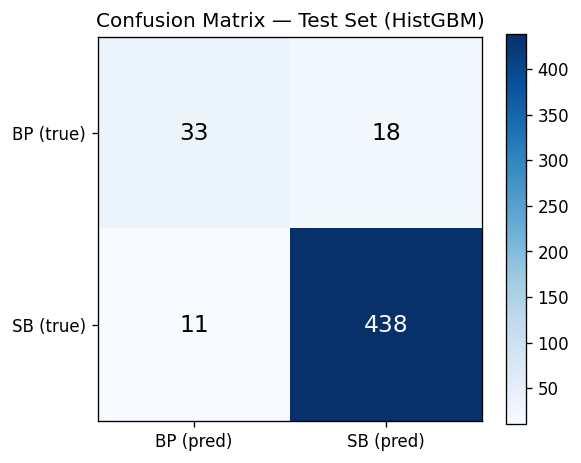

Saved confusion_matrix.png


In [25]:
# ── Confusion matrix heatmap ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_test, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['BP (pred)', 'SB (pred)'])
ax.set_yticklabels(['BP (true)', 'SB (true)'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_test[i,j]), ha='center', va='center', fontsize=14,
                color='white' if cm_test[i,j] > cm_test.max()*0.5 else 'black')
ax.set_title('Confusion Matrix — Test Set (HistGBM)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved figures/confusion_matrix.png')

In [26]:
# ── Misclassification samples ─────────────────────────────────────────────────

test_df = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': y_pred_test})

# False negatives: substantive predicted as boilerplate (most costly)
fn = test_df[(test_df.true == 1) & (test_df.pred == 0)]
# False positives: boilerplate predicted as substantive
fp = test_df[(test_df.true == 0) & (test_df.pred == 1)]

print(f'False negatives (SB→BP): {len(fn)}')
print(f'False positives (BP→SB): {len(fp)}')

print('\n--- False negatives (substantive labelled as boilerplate) ---')
for _, row in fn.head(8).iterrows():
    print(f'  "{row.text[:120]}"')

print('\n--- False positives (boilerplate labelled as substantive) ---')
for _, row in fp.head(8).iterrows():
    print(f'  "{row.text[:120]}"')

False negatives (SB→BP): 11
False positives (BP→SB): 18

--- False negatives (substantive labelled as boilerplate) ---
  "I don't know if he's nailed it down yet, but we'll be getting that information out shortly."
  "I don't know all the efforts we're involved in, but to the extent we're involved in these efforts, I and most Palantiria"
  "I was just so delighted to see how well that they have done, the moral of the team and how the team is working together."
  "I continue to be excited by the opportunities and the sheer potential of our franchise."
  "In Converse, the team took some decisive steps this quarter to bring the brand back to a healthy business."
  "And done properly, as we talk about on the slide, we're very happy to be lenders to them."
  "So we're in a kind of the pole position in that regard."
  "Executives - CEO & Chair of the Board
Let me just -- so let me just be clear about where the ones that we've just done a"

--- False positives (boilerplate labelled as substan

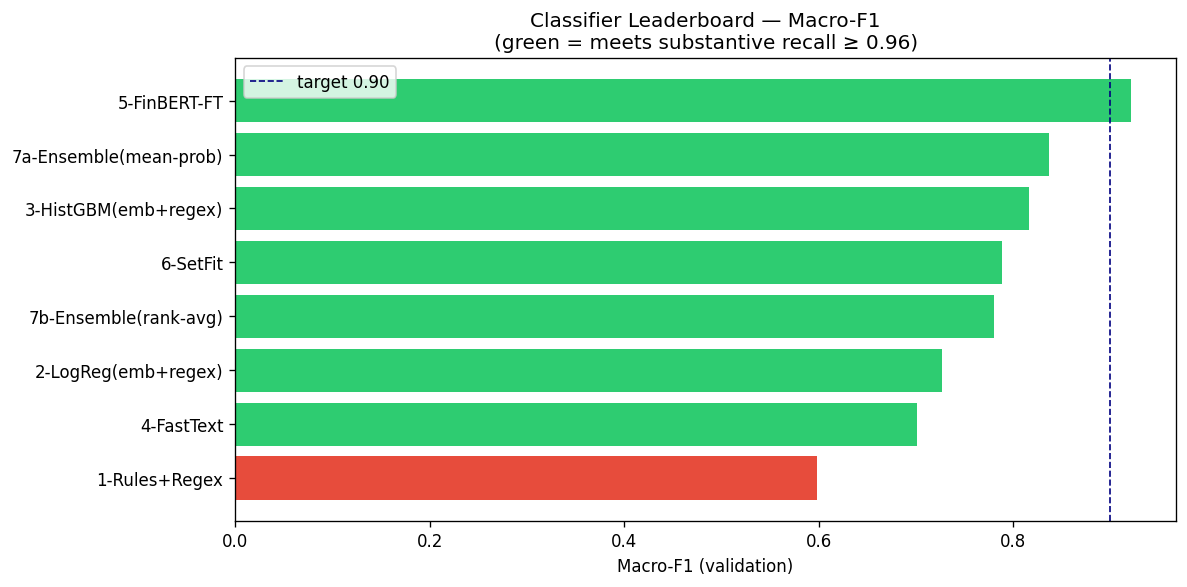

Saved leaderboard.png


In [27]:
# ── Final leaderboard plot ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if m else '#e74c3c' for m in lb_df['meets_floor']]
bars = ax.barh(lb_df['model'][::-1], lb_df['macro_f1'][::-1], color=colors[::-1])
ax.axvline(0.9, color='navy', linestyle='--', linewidth=1, label='target 0.90')
ax.set_xlabel('Macro-F1 (validation)')
ax.set_title('Classifier Leaderboard — Macro-F1\n(green = meets substantive recall ≥ 0.96)')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'leaderboard.png', dpi=150)
plt.show()
print('Saved figures/leaderboard.png')